In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline

from scipy.stats import boxcox

In [2]:
df = pd.read_csv("../data/winequality-red.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [4]:
df.drop_duplicates(inplace=True)

In [5]:
df['quality'] = (df['quality'] >= 6).astype(int)

# BASELINE MODEL

In [6]:
X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

pred = model.predict(X_test_scaled)

baseline_accuracy = accuracy_score(y_test, pred)

print(baseline_accuracy)

0.7685589519650655


# Polynomial Features

In [9]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

In [10]:
poly_model = LogisticRegression(max_iter=2000)

poly_model.fit(X_train_poly, y_train)

poly_pred = poly_model.predict(X_test_poly)

poly_accuracy = accuracy_score(y_test, poly_pred)

print(poly_accuracy)

0.7510917030567685


# Interaction Features

In [17]:
interaction = PolynomialFeatures(
    degree=2,
    interaction_only=True,
    include_bias=False
)

X_train_inter = interaction.fit_transform(X_train_scaled)
X_test_inter = interaction.transform(X_test_scaled)

In [18]:
interaction_model = LogisticRegression(max_iter=2000)

interaction_model.fit(X_train_inter, y_train)

interaction_pred = interaction_model.predict(X_test_inter)

interaction_accuracy = accuracy_score(y_test, interaction_pred)

print("Interaction Features Accuracy:", interaction_accuracy)

Interaction Features Accuracy: 0.7641921397379913


# Log Transformation

In [26]:
skew_cols = [
    'chlorides',
    'sulphates',
    'residual sugar'
]


In [27]:
log_df = X.copy()

for col in skew_cols:
    log_df[col] = np.log1p(log_df[col])

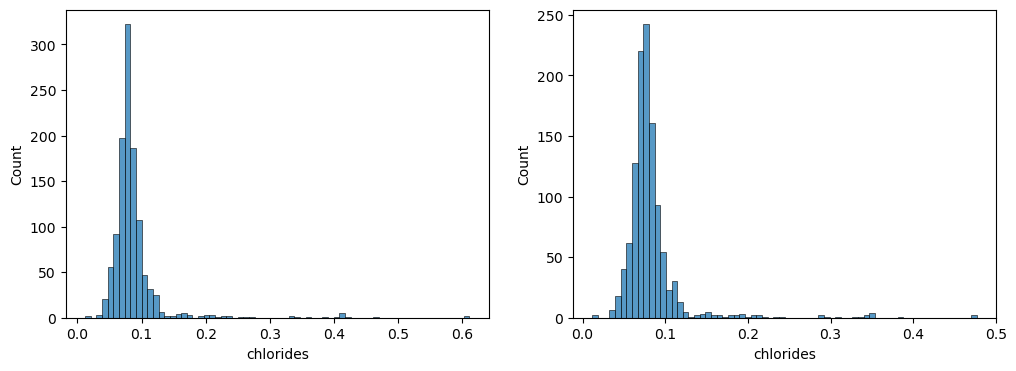

In [28]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.histplot(df['chlorides'], ax=ax[0])

sns.histplot(log_df['chlorides'], ax=ax[1])

plt.show()

# Train Model on Log - Transformed Features

In [30]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    log_df,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_log = scaler.fit_transform(X_train_log)
X_test_log = scaler.transform(X_test_log)

log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train_log, y_train_log)

log_pred = log_model.predict(X_test_log)

log_accuracy = accuracy_score(y_test_log, log_pred)

print("Log Transformation Accuracy:", log_accuracy)

Log Transformation Accuracy: 0.759825327510917


In [31]:
print(classification_report(y_test_log, log_pred))

              precision    recall  f1-score   support

           0       0.72      0.75      0.73       102
           1       0.79      0.77      0.78       127

    accuracy                           0.76       229
   macro avg       0.76      0.76      0.76       229
weighted avg       0.76      0.76      0.76       229



# Box-Cox Transformation

In [32]:
box_df = X.copy()

for col in skew_cols:
    box_df[col], _ = boxcox(box_df[col] + 1)

# Train Model on Box-Cox Features

In [33]:
X_train_box, X_test_box, y_train_box, y_test_box = train_test_split(
    box_df,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_box = scaler.fit_transform(X_train_box)
X_test_box = scaler.transform(X_test_box)

box_model = LogisticRegression(max_iter=2000)

box_model.fit(X_train_box, y_train_box)

box_pred = box_model.predict(X_test_box)

boxcox_accuracy = accuracy_score(y_test_box, box_pred)

print("Box-Cox Accuracy:", boxcox_accuracy)

Box-Cox Accuracy: 0.7467248908296943


In [34]:
print(classification_report(y_test_box, box_pred))

              precision    recall  f1-score   support

           0       0.72      0.72      0.72       102
           1       0.77      0.77      0.77       127

    accuracy                           0.75       229
   macro avg       0.74      0.74      0.74       229
weighted avg       0.75      0.75      0.75       229



# Comparison

In [35]:
results = pd.DataFrame({
    'Method': [
        'Baseline',
        'Polynomial',
        'Interaction',
        'Log Transform',
        'Box-Cox'
    ],
    'Accuracy': [
        baseline_accuracy,
        poly_accuracy,
        interaction_accuracy,
        log_accuracy,
        boxcox_accuracy
    ]
})

print(results)

          Method  Accuracy
0       Baseline  0.768559
1     Polynomial  0.751092
2    Interaction  0.764192
3  Log Transform  0.759825
4        Box-Cox  0.746725


# Visualization

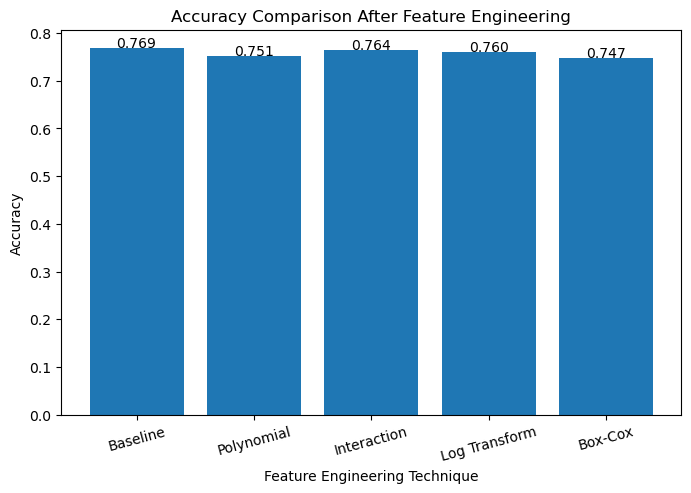

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(results['Method'], results['Accuracy'])

plt.title("Accuracy Comparison After Feature Engineering")
plt.xlabel("Feature Engineering Technique")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

for i, value in enumerate(results['Accuracy']):
    plt.text(i, value + 0.002, f"{value:.3f}", ha='center')

plt.show()